# Task 1 — Prove why we visualize
Dataset: `datasaurus.csv`, 1846 rows, 13 datasets of 142 points each.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (colour-blind safe, same as the lecture notebook) ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "legend.fontsize": 10, "lines.linewidth": 2, "font.size": 11,
    "savefig.dpi": 150, "savefig.bbox": "tight",
})

def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)

def note(ax, text, y=-0.2):
    """Footnote under a chart - used to say what was excluded."""
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

In [2]:
ds = pd.read_csv(DATA / "datasaurus.csv")
print(ds.shape, ds.dataset.nunique())
ds.head()

(1846, 3) 13


,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


## 1. Summary stats for each of the 13 datasets

In [3]:
summary = ds.groupby("dataset").agg(
    n=("x", "size"), mean_x=("x", "mean"), mean_y=("y", "mean"),
    std_x=("x", "std"), std_y=("y", "std"),
).round(2)
summary["corr_xy"] = ds.groupby("dataset").apply(lambda g: g.x.corr(g.y), include_groups=False).round(3)
summary

,n,mean_x,mean_y,std_x,std_y,corr_xy
dataset,,,,,,
away,142,54.27,47.83,16.77,26.94,-0.064
bullseye,142,54.27,47.83,16.77,26.94,-0.069
circle,142,54.27,47.84,16.76,26.93,-0.068
dino,142,54.26,47.83,16.77,26.94,-0.064
dots,142,54.26,47.84,16.77,26.93,-0.060
h_lines,142,54.26,47.83,16.77,26.94,-0.062
high_lines,142,54.27,47.84,16.77,26.94,-0.069
slant_down,142,54.27,47.84,16.77,26.94,-0.069
slant_up,142,54.27,47.83,16.77,26.94,-0.069


## 2. What the table alone would tell you
Every row is basically the same: n=142, mean x around 54.3, mean y around 47.8, std x around 16.8,
std y around 26.9, correlation around -0.06 to -0.07. If this table was all I had I'd conclude these
are 13 samples of the same underlying data, maybe just noisy draws from one distribution. Nothing in
the numbers hints that they look different at all.

## 3. Now plot them

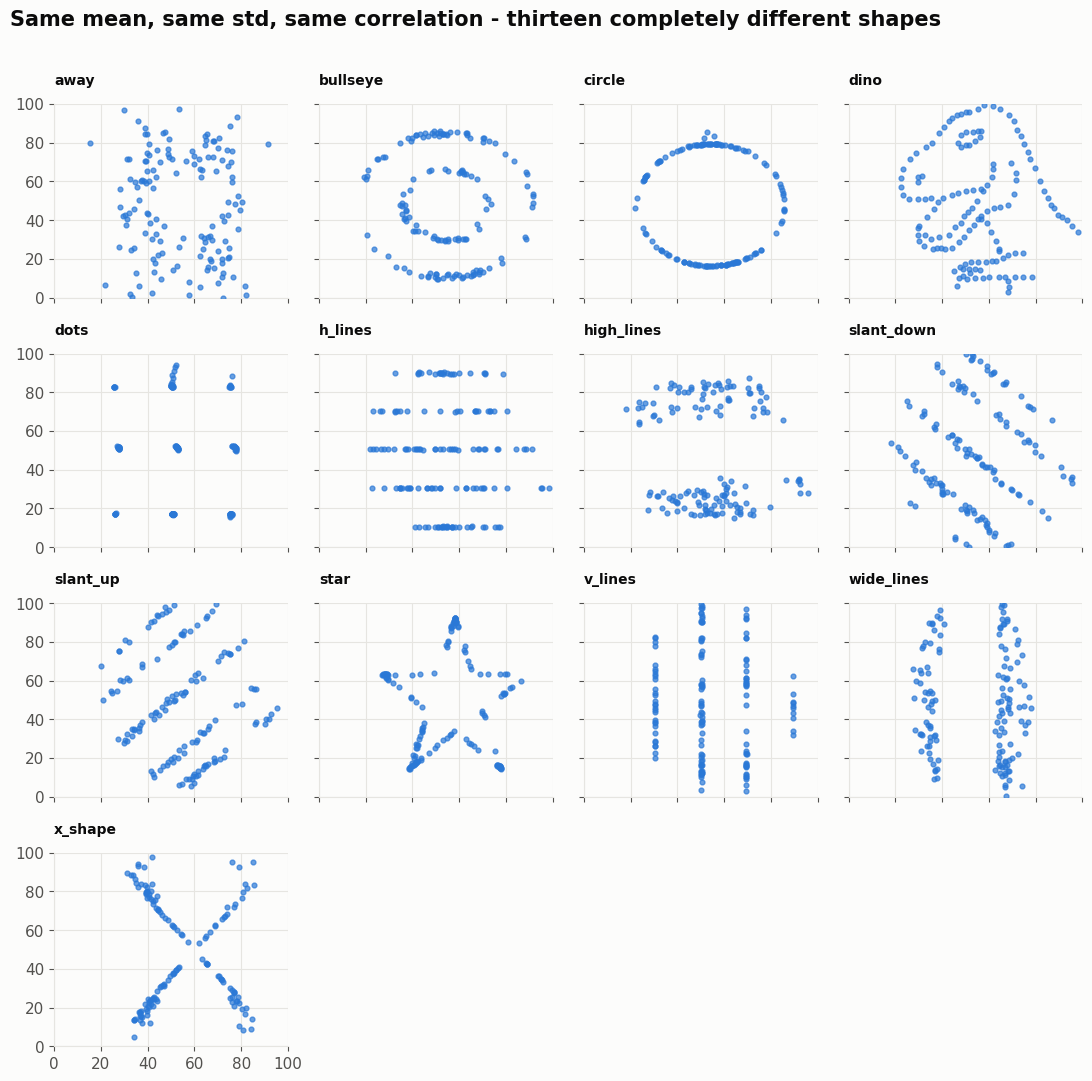

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(11, 11), sharex=True, sharey=True)
for ax, (name, group) in zip(axes.flat, ds.groupby("dataset")):
    ax.scatter(group.x, group.y, s=12, color=BLUE, alpha=0.7, zorder=3)
    ax.set_title(name, fontsize=10)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
for ax in axes.flat[13:]:
    ax.axis("off")
fig.suptitle("Same mean, same std, same correlation - thirteen completely different shapes",
             x=0.01, ha="left", fontsize=15, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save(fig, "t1_grid")
plt.show()

## 4. What's actually going on
It's a dinosaur, a star, an X, concentric circles, straight lines running in every direction, a
bullseye, scattered dots — shapes with nothing statistically in common except that someone (the
authors of the datasaurus paper) deliberately optimized them to share the same mean, std and
correlation to two decimal places. The table in step 1 is not lying, it's just the wrong amount of
information: four numbers per dataset can't carry the shape of 142 points, so two datasets can agree
on every number and disagree on everything else.

## Does 13 datasets of 142 points beat Anscombe's 4 datasets of 11?
No, not in the way that matters. More datasets and more points per dataset makes each individual
mean/std/correlation estimate more numerically stable — 142 points gives you a less noisy standard
deviation than 11 points would. But stability of the statistic doesn't tell you anything about whether
the statistic is the right summary of the shape. The datasaurus set proves this more dramatically than
Anscombe's, not less: it's got more datasets, more points, *and* they still fool you just as hard,
because the dataset was specifically built to make the point survive at scale. The size of the data
isn't what makes a summary statistic trustworthy — the shape of the data is what you don't know until
you look.